## 1. Carga de librerías

Se importan las librerías necesarias para cargar datos, optimizar el modelo y comparar resultados.

In [3]:
# Librerías principales
import pandas as pd
import numpy as np
import joblib
import os

# Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Optimización y métricas
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

## 2. Carga de datos y modelo base

Se cargan las particiones usadas en los notebooks anteriores y el modelo Random Forest base.

In [4]:
# Cargamos datos de entrenamiento y prueba
classification_data = joblib.load("../results/metrics/classification_train_test_data.pkl")

X_train_clf = classification_data["X_train"]
X_test_clf = classification_data["X_test"]
y_train_clf = classification_data["y_train"]
y_test_clf = classification_data["y_test"]

In [6]:
# Cargamos el modelo Random Forest base
base_model_path = "../models/trained_models/random_forest_classification_base.pkl"

rf_base_model = joblib.load(base_model_path)

rf_base_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

## 3. Evaluación del modelo base

Antes de optimizar, se calcula el rendimiento del Random Forest base para compararlo después con el modelo optimizado.

In [7]:
# Predicción del modelo base
y_pred_base = rf_base_model.predict(X_test_clf)

# Métricas del modelo base
base_metrics = {
    "model": "Random Forest Base",
    "accuracy": accuracy_score(y_test_clf, y_pred_base),
    "precision": precision_score(y_test_clf, y_pred_base, zero_division=0),
    "recall": recall_score(y_test_clf, y_pred_base, zero_division=0),
    "f1_score": f1_score(y_test_clf, y_pred_base, zero_division=0)
}

base_metrics

{'model': 'Random Forest Base',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0}

## 4. Hiperparámetros a probar

Se define una búsqueda simple de hiperparámetros para Random Forest. Se prueban combinaciones de cantidad de árboles, profundidad máxima y mínimo de muestras para dividir nodos.

In [8]:
# Parámetros simples para no hacer la búsqueda demasiado pesada
param_grid = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

param_grid

{'model__n_estimators': [50, 100],
 'model__max_depth': [None, 5, 10],
 'model__min_samples_split': [2, 5]}

## 5. Optimización con GridSearchCV

Se usa GridSearchCV para probar combinaciones de hiperparámetros y elegir la mejor según F1-score.

In [9]:
# Búsqueda de mejores hiperparámetros
grid_search = GridSearchCV(
    estimator=rf_base_model,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

grid_search.fit(X_train_clf, y_train_clf)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 5, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [50, 100]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is dis

## 6. Mejores hiperparámetros

Se revisa qué combinación obtuvo el mejor resultado durante la búsqueda.

In [10]:
# Mejores parámetros y mejor score
print("Mejores parámetros:")
print(grid_search.best_params_)

print("Mejor F1 en validación cruzada:")
print(grid_search.best_score_)

Mejores parámetros:
{'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 100}
Mejor F1 en validación cruzada:
1.0


## 7. Evaluación del modelo optimizado

Se evalúa el mejor modelo encontrado sobre el conjunto de prueba.

In [11]:
# Mejor modelo encontrado por GridSearchCV
rf_optimized_model = grid_search.best_estimator_

# Predicción del modelo optimizado
y_pred_optimized = rf_optimized_model.predict(X_test_clf)

# Métricas del modelo optimizado
optimized_metrics = {
    "model": "Random Forest Optimized",
    "accuracy": accuracy_score(y_test_clf, y_pred_optimized),
    "precision": precision_score(y_test_clf, y_pred_optimized, zero_division=0),
    "recall": recall_score(y_test_clf, y_pred_optimized, zero_division=0),
    "f1_score": f1_score(y_test_clf, y_pred_optimized, zero_division=0)
}

optimized_metrics

{'model': 'Random Forest Optimized',
 'accuracy': 1.0,
 'precision': 1.0,
 'recall': 1.0,
 'f1_score': 1.0}

## 8. Comparación base vs optimizado

Se comparan las métricas del Random Forest base y del Random Forest optimizado.

In [12]:
# Tabla comparativa
optimization_comparison_df = pd.DataFrame([
    base_metrics,
    optimized_metrics
])

optimization_comparison_df

,model,accuracy,precision,recall,f1_score
0,Random Forest Base,1.0,1.0,1.0,1.0
1,Random Forest Optimized,1.0,1.0,1.0,1.0


In [13]:
# Guardamos comparación
optimization_comparison_df.to_csv(
    "../results/metrics/optimized_model_metrics.csv",
    index=False
)

## 9. Gráfico de comparación

Se grafica el F1-score del modelo base y del modelo optimizado.

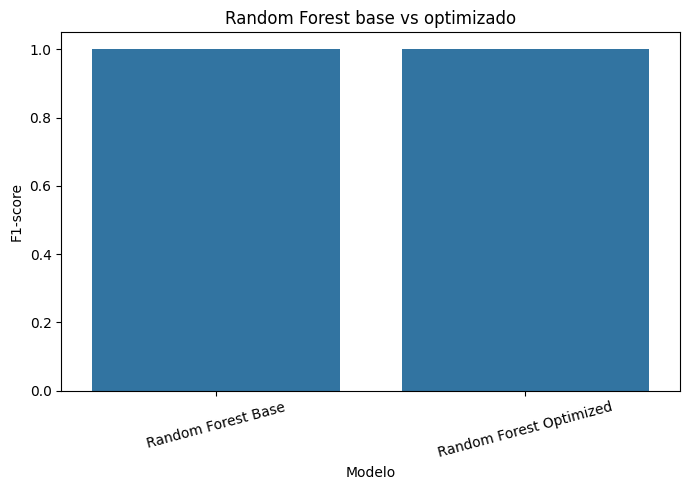

In [14]:
# Comparación de F1-score
plt.figure(figsize=(7, 5))

sns.barplot(
    data=optimization_comparison_df,
    x="model",
    y="f1_score"
)

plt.title("Random Forest base vs optimizado")
plt.xlabel("Modelo")
plt.ylabel("F1-score")
plt.xticks(rotation=15)
plt.tight_layout()

plt.savefig("../results/plots/random_forest_base_vs_optimized.png")
plt.show()

## 10. Matriz de confusión del modelo optimizado

Se revisa la matriz de confusión del modelo optimizado para ver sus aciertos y errores.

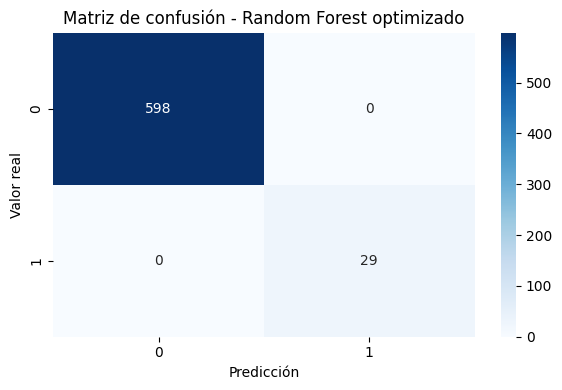

In [15]:
# Matriz de confusión del modelo optimizado
cm_optimized = confusion_matrix(y_test_clf, y_pred_optimized)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_optimized,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de confusión - Random Forest optimizado")
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.tight_layout()

plt.savefig("../results/plots/confusion_matrix_optimized_model.png")
plt.show()

## 11. Reporte del modelo optimizado

Se revisan las métricas por clase del modelo optimizado.

In [16]:
# Reporte detallado del modelo optimizado
print(classification_report(y_test_clf, y_pred_optimized, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       598
           1       1.00      1.00      1.00        29

    accuracy                           1.00       627
   macro avg       1.00      1.00      1.00       627
weighted avg       1.00      1.00      1.00       627



Este reporte permite revisar si el modelo optimizado mantiene buen rendimiento tanto en la clase 0 como en la clase 1.

## 12. Guardado del modelo optimizado

Se guarda el mejor modelo para usarlo en el análisis final.

In [17]:
# Creamos carpeta si no existe
os.makedirs("../models/trained_models", exist_ok=True)

# Guardamos el modelo optimizado
optimized_model_path = "../models/trained_models/random_forest_optimized.pkl"

joblib.dump(rf_optimized_model, optimized_model_path)

print(f"Modelo optimizado guardado en: {optimized_model_path}")

Modelo optimizado guardado en: ../models/trained_models/random_forest_optimized.pkl


## 13. Guardado de mejores parámetros

Se guardan los mejores hiperparámetros encontrados por GridSearchCV.

In [18]:
# Guardamos los mejores parámetros
best_params_df = pd.DataFrame([grid_search.best_params_])

best_params_df.to_csv(
    "../results/metrics/best_hyperparameters.csv",
    index=False
)

best_params_df

,model__max_depth,model__min_samples_split,model__n_estimators
0,None,5,100


## 14. Cierre de optimización

En este notebook se optimizó Random Forest usando GridSearchCV. Luego se comparó el modelo base contra el modelo optimizado para revisar si hubo mejora en el rendimiento.

Estos resultados se usarán en el análisis final del proyecto.